In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl

# plt.style.use('dark_background')


## **Importing Data**

In [5]:
train = pd.read_csv("Data/train.csv")
test = pd.read_csv("Data/test.csv")
oil = pd.read_csv("Data/oil.csv")
stores = pd.read_csv("Data/stores.csv")
transactions = pd.read_csv("Data/transactions.csv")
holidays_events = pd.read_csv("Data/holidays_events.csv")
sample_submission = pd.read_csv("Data/sample_submission.csv")

In [6]:
test['test'] = 1
train['test'] = 0
df = pd.concat([train, test], axis=0)

In [7]:
df

,id,date,store_nbr,family,sales,onpromotion,test
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,0
1,1,2013-01-01,1,BABY CARE,0.0,0,0
2,2,2013-01-01,1,BEAUTY,0.0,0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,0
4,4,2013-01-01,1,BOOKS,0.0,0,0
...,...,...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,NaN,1,1
28508,3029396,2017-08-31,9,PREPARED FOODS,NaN,0,1
28509,3029397,2017-08-31,9,PRODUCE,NaN,1,1
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,NaN,9,1


In [8]:
df.isna().mean()

id             0.000000
date           0.000000
store_nbr      0.000000
family         0.000000
sales          0.009412
onpromotion    0.000000
test           0.000000
dtype: float64

In [9]:
(df['test']==0).mean()

np.float64(0.9905882352941177)

In [10]:
df.dtypes

id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
test             int64
dtype: object

## **Data analysis and vizualization**

In [11]:
def datetime(df):
    df['date'] = pd.to_datetime(df["date"])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['day_of_week'] = df['date'].dt.day_of_week
    df['day_name'] = df['date'].dt.day_name()
    df['quarter'] = df['date'].dt.quarter
    df['is_leap_year'] = df['date'].dt.is_leap_year
    return df

In [12]:
df = datetime(df)

In [13]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,test,year,month,day,day_of_week,day_name,quarter,is_leap_year
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,0,2013,1,1,1,Tuesday,1,False
1,1,2013-01-01,1,BABY CARE,0.0,0,0,2013,1,1,1,Tuesday,1,False
2,2,2013-01-01,1,BEAUTY,0.0,0,0,2013,1,1,1,Tuesday,1,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,0,2013,1,1,1,Tuesday,1,False
4,4,2013-01-01,1,BOOKS,0.0,0,0,2013,1,1,1,Tuesday,1,False


<Axes: xlabel='date', ylabel='sales'>

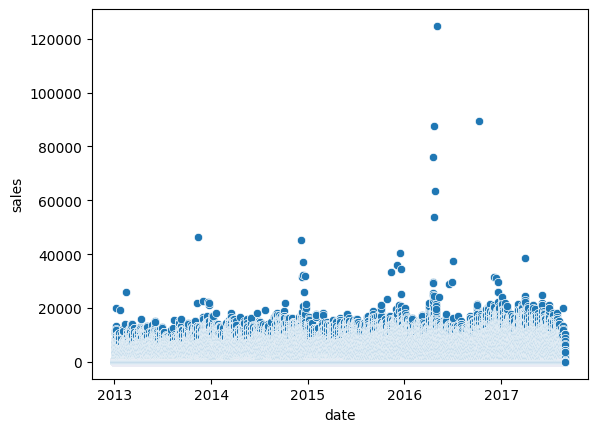

In [14]:
sns.scatterplot(df, x='date', y='sales', )

In [15]:
df.loc[df['sales'] > 20000].head()

,id,date,store_nbr,family,sales,onpromotion,test,year,month,day,day_of_week,day_name,quarter,is_leap_year
79674,79674,2013-02-14,44,GROCERY I,26067.0,0,0,2013,2,14,3,Thursday,1,False
553686,553686,2013-11-07,44,GROCERY I,22024.0,0,0,2013,11,7,3,Thursday,4,False
562596,562596,2013-11-12,44,GROCERY I,46271.0,0,0,2013,11,12,1,Tuesday,4,False
598236,598236,2013-12-02,44,GROCERY I,22534.0,0,0,2013,12,2,0,Monday,4,False
629949,629949,2013-12-20,34,GROCERY I,22125.0,0,0,2013,12,20,4,Friday,4,False


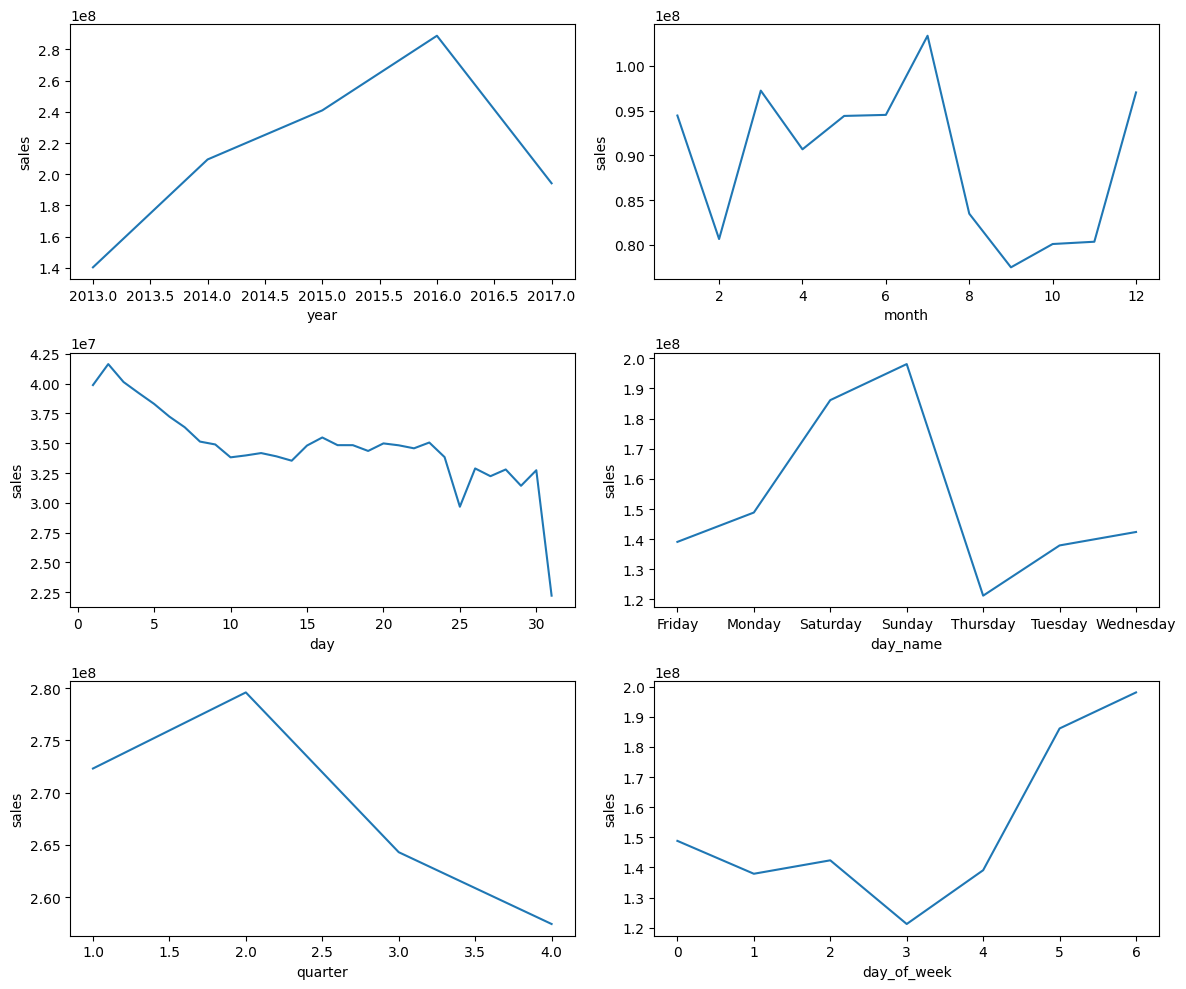

In [16]:
grouping_columns = ['year', 'month', 'day', 'day_name', 'quarter', 'day_of_week']

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ind, column in enumerate(grouping_columns):
    grouped_data = df.groupby(column)['sales'].sum()
    grouped_data = pd.DataFrame(grouped_data).reset_index()

    sns.lineplot(data=grouped_data, x=column, y='sales', ax=axes[ind])

plt.tight_layout()
plt.show()

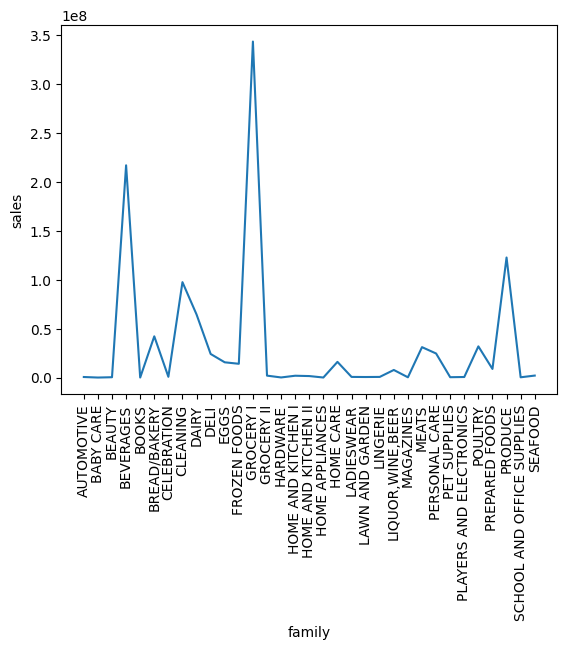

In [17]:
grouped_data = df.groupby('family')['sales'].sum().reset_index()

sns.lineplot(data=grouped_data, x='family', y='sales')

ax = plt.gca()
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

In [18]:
pd.DataFrame(df.groupby('year')['sales'].sum()).reset_index().sort_values(by='sales', ascending=False)

,year,sales
3,2016,2.886545e+08
2,2015,2.408801e+08
1,2014,2.094742e+08
4,2017,1.942171e+08
0,2013,1.404190e+08


<Axes: xlabel='store_nbr', ylabel='sales'>

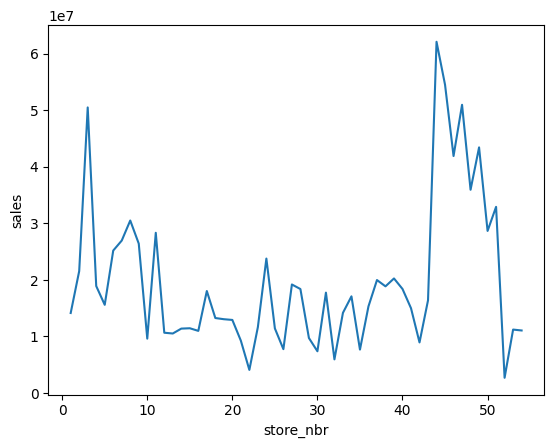

In [19]:
best_store = df.groupby('store_nbr')['sales'].sum().reset_index()

bs_sorted = best_store.sort_values(by='sales', ascending=False)

sns.lineplot(data=bs_sorted, x='store_nbr', y='sales')

In [20]:
best_city = pd.merge(bs_sorted, stores, on='store_nbr', how='left')

best_city['ratio'] = 0

for city in best_city['city'].unique():
    ratio = len(best_city.loc[best_city['city'] == city]) / len(best_city)
    best_city.loc[best_city['city'] == city, 'ratio'] = ratio

best_city.head()

C:\Users\rosha\AppData\Local\Temp\ipykernel_29548\1541336069.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3333333333333333' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  best_city.loc[best_city['city'] == city, 'ratio'] = ratio


,store_nbr,sales,city,state,type,cluster,ratio
0,44,6.208755e+07,Quito,Pichincha,A,5,0.333333
1,45,5.449801e+07,Quito,Pichincha,A,11,0.333333
2,47,5.094831e+07,Quito,Pichincha,A,14,0.333333
3,3,5.048191e+07,Quito,Pichincha,D,8,0.333333
4,49,4.342010e+07,Quito,Pichincha,A,11,0.333333


In [21]:
best_city.sort_values(by='sales', ascending=True).head()

,store_nbr,sales,city,state,type,cluster,ratio
53,52,2.696170e+06,Manta,Manabi,A,11,0.037037
52,22,4.090202e+06,Puyo,Pastaza,C,7,0.018519
51,32,5.951796e+06,Guayaquil,Guayas,C,3,0.148148
50,30,7.382074e+06,Guayaquil,Guayas,C,3,0.148148
49,35,7.676679e+06,Playas,Guayas,C,3,0.018519


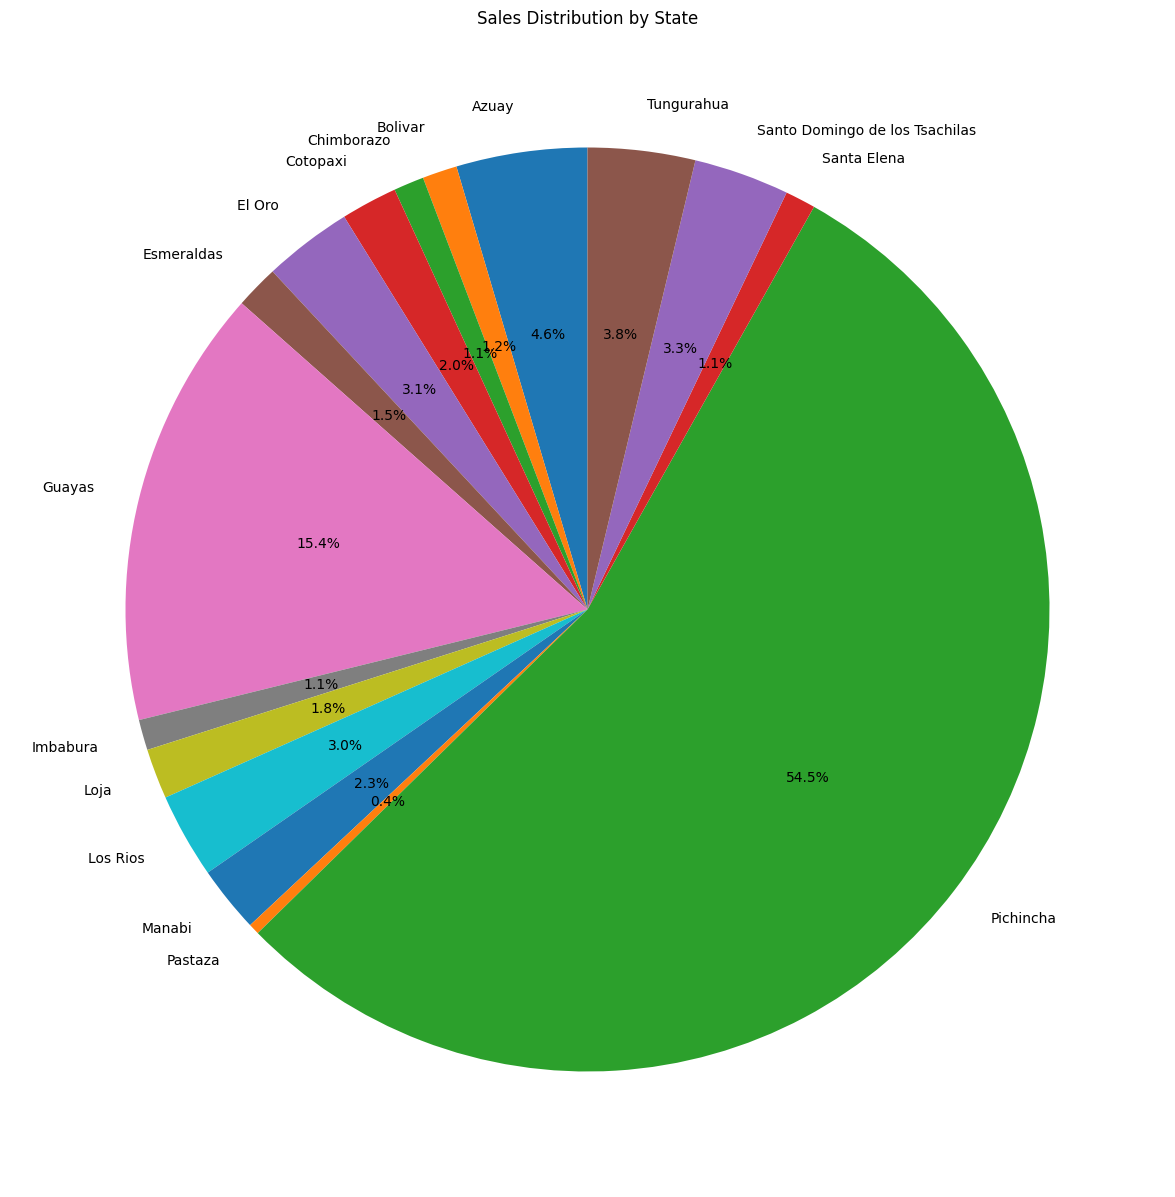

In [22]:
data = best_city.groupby('state')['sales'].sum()

plt.figure(figsize=(15, 15))
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)

plt.title('Sales Distribution by State')

plt.show()

In [23]:
best_city.groupby('city')['ratio'].apply(lambda x: x[0:1])/best_city.groupby('city')['sales'].sum()

city             
Ambato         9     9.189328e-10
Babahoyo       24    1.043481e-09
Cayambe        10    6.537742e-10
Cuenca         16    1.129899e-09
Daule          18    9.651083e-10
El Carmen      40    1.674750e-09
Esmeraldas     26    1.129750e-09
Guaranda       33    1.419097e-09
Guayaquil      7     1.204777e-09
Ibarra         36    1.617158e-09
Latacunga      42    1.748493e-09
Libertad       28    1.208589e-09
Loja           20    9.818939e-10
Machala        21    1.109332e-09
Manta          39    2.662172e-09
Playas         49    2.412308e-09
Puyo           52    4.527532e-09
Quevedo        30    1.306098e-09
Quito          0     5.987215e-10
Riobamba       38    1.626155e-09
Salinas        37    1.621445e-09
Santo Domingo  27    1.550345e-09
dtype: float64

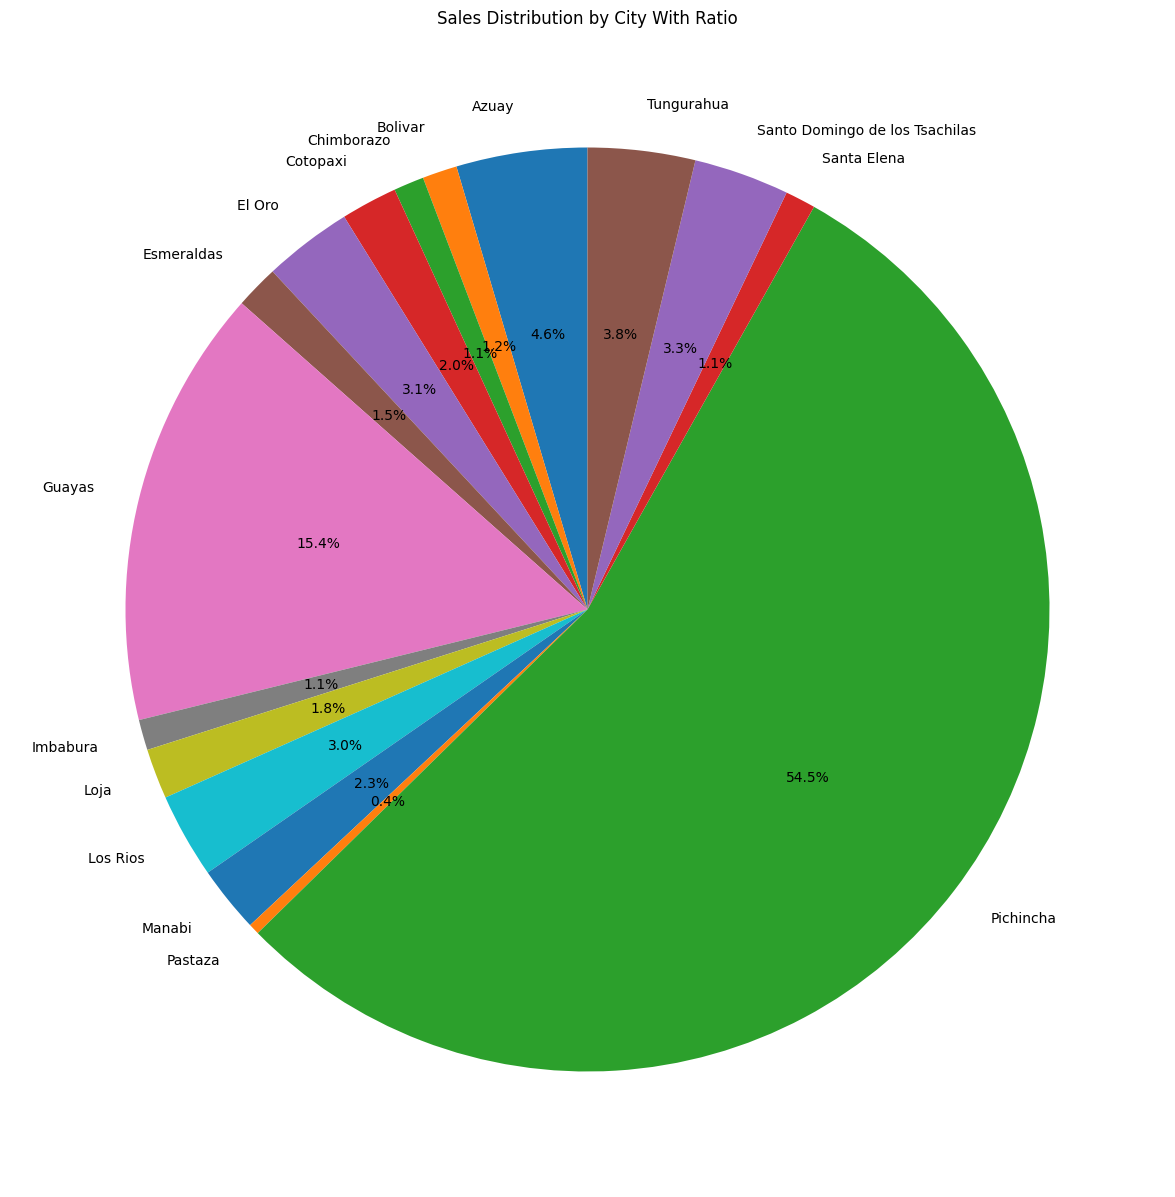

In [24]:
best_city.groupby('city')['ratio'].apply(lambda x: x[0:1])/best_city.groupby('city')['sales'].sum()

plt.figure(figsize=(15, 15))
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)

plt.title('Sales Distribution by City With Ratio')

plt.show()

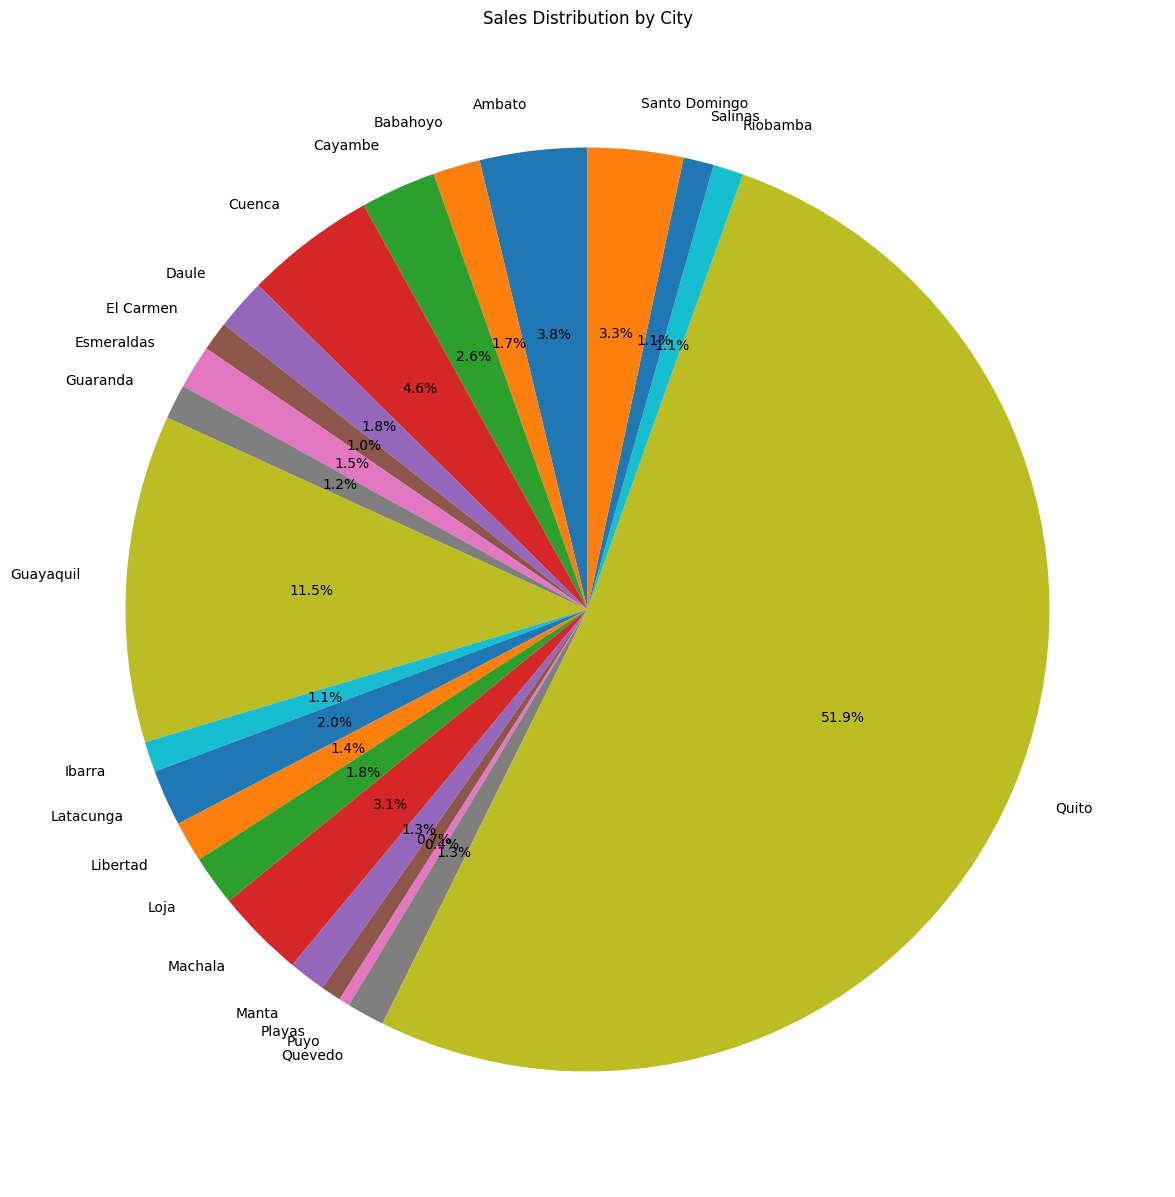

In [25]:
data = best_city.groupby('city')['sales'].sum()

plt.figure(figsize=(15, 15))
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)

plt.title('Sales Distribution by City')

plt.show()

In [26]:
df = pd.merge(df, stores, how='left', on='store_nbr')

In [27]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,test,year,month,day,day_of_week,day_name,quarter,is_leap_year,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,0,2013,1,1,1,Tuesday,1,False,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,0,2013,1,1,1,Tuesday,1,False,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,0,2013,1,1,1,Tuesday,1,False,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,0,2013,1,1,1,Tuesday,1,False,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,0,2013,1,1,1,Tuesday,1,False,Quito,Pichincha,D,13


In [28]:
pd.DataFrame(df.groupby('cluster')['sales'].sum()).reset_index().sort_values(by='sales', ascending=True).head(10)

,cluster,sales
15,16,1.325938e+07
6,7,1.547812e+07
11,12,1.803097e+07
1,2,2.891640e+07
8,9,3.056108e+07
16,17,3.291149e+07
3,4,4.944344e+07
0,1,5.437675e+07
14,15,5.529695e+07
4,5,6.208755e+07


In [29]:
holidays_events

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False


In [30]:
holidays_events['date'] = pd.to_datetime(holidays_events["date"])
df = pd.merge(df, holidays_events, how='left', on='date')

In [31]:
df_non_nan = df.dropna(subset=['locale'])
df_non_nan.head()

,id,date,store_nbr,family,sales,onpromotion,test,year,month,day,...,is_leap_year,city,state,type_x,cluster,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,0,2013,1,1,...,False,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,0,2013,1,1,...,False,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,0,2013,1,1,...,False,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,0,2013,1,1,...,False,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,0,2013,1,1,...,False,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False


In [32]:
df_non_nan['type_y'].value_counts()

type_y
Holiday       306504
Event          99792
Additional     67716
Transfer       16038
Work Day        8910
Bridge          5346
Name: count, dtype: int64

In [33]:
df_non_nan['locale'].value_counts()

locale
National    261954
Local       210276
Regional     32076
Name: count, dtype: int64

In [34]:
df_non_nan.groupby(['type_y', 'family'])['sales'].sum()

type_y      family                    
Additional  AUTOMOTIVE                    1.496400e+04
            BABY CARE                     3.050000e+02
            BEAUTY                        9.801000e+03
            BEVERAGES                     6.183568e+06
            BOOKS                         3.100000e+02
                                              ...     
Work Day    POULTRY                       9.566624e+04
            PREPARED FOODS                2.989535e+04
            PRODUCE                       2.425016e+05
            SCHOOL AND OFFICE SUPPLIES    1.520000e+02
            SEAFOOD                       6.645205e+03
Name: sales, Length: 198, dtype: float64

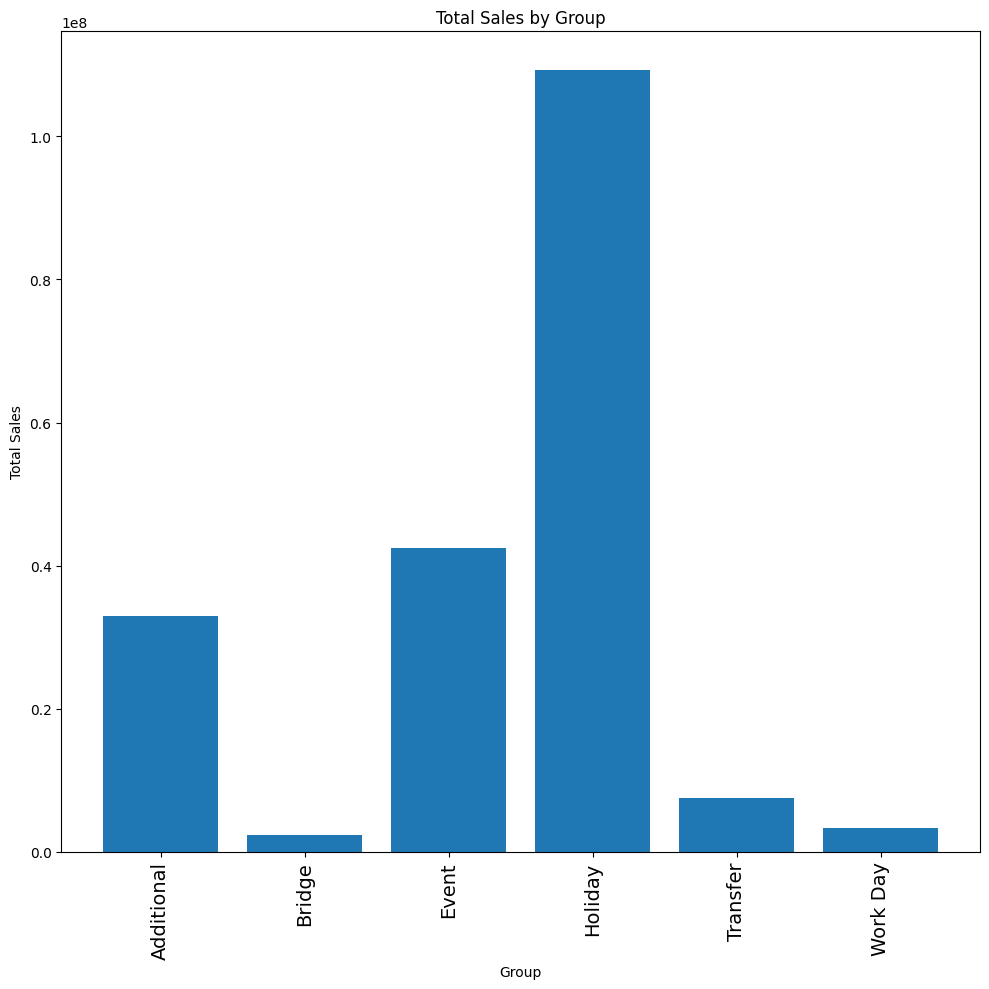

In [35]:
grouped_data = df_non_nan.groupby(['type_y'])['sales'].sum()

grouped_data = grouped_data.reset_index()

plt.figure(figsize=(10, 10))
plt.bar(range(len(grouped_data)), grouped_data['sales'])
plt.xlabel('Group')
plt.ylabel('Total Sales')
plt.title('Total Sales by Group')
plt.xticks(range(len(grouped_data)), grouped_data['type_y'], rotation=90, fontsize=14)
plt.tight_layout()
plt.show()

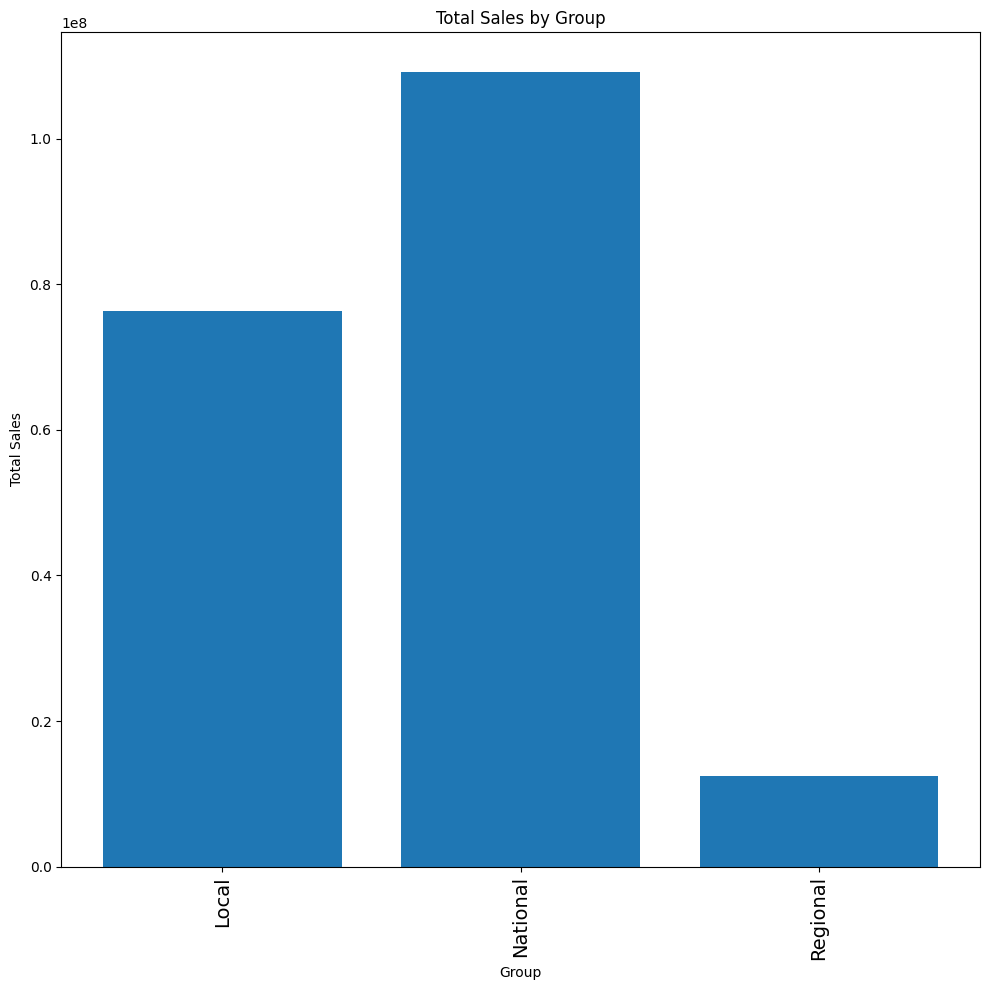

In [36]:
grouped_data = df_non_nan.groupby(['locale'])['sales'].sum()

grouped_data = grouped_data.reset_index()

plt.figure(figsize=(10, 10))
plt.bar(range(len(grouped_data)), grouped_data['sales'])
plt.xlabel('Group')
plt.ylabel('Total Sales')
plt.title('Total Sales by Group')
plt.xticks(range(len(grouped_data)), grouped_data['locale'], rotation=90, fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
df_non_nan[df_non_nan['transferred'] == True].groupby('locale')['sales'].sum()

locale
Local       1.489146e+06
National    3.507657e+06
Name: sales, dtype: float64

## **Feature Engineering**

In [38]:
(df['test']==0).mean()

np.float64(0.9907514450867052)

In [39]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categories = ['family', 'city', 'locale', 'type_y', 'type_x', 'state']

for col in categories:
    df[col + '_enc'] = label_encoder.fit_transform(df[col])

In [40]:
df['type_y'] = df['type_y'].fillna(0)

df['transferred'] = df['transferred'].fillna(0.0).astype(float)

df['locale'] = df['locale'].fillna(0)

categorical_features = ['family', 'city', 'state']

df = pd.get_dummies(df, columns=categorical_features)

df['is_leap_year'] = df['is_leap_year'].astype(int)

In [41]:
df.head()

,id,date,store_nbr,sales,onpromotion,test,year,month,day,day_of_week,...,state_Guayas,state_Imbabura,state_Loja,state_Los Rios,state_Manabi,state_Pastaza,state_Pichincha,state_Santa Elena,state_Santo Domingo de los Tsachilas,state_Tungurahua
0,0,2013-01-01,1,0.0,0,0,2013,1,1,1,...,False,False,False,False,False,False,True,False,False,False
1,1,2013-01-01,1,0.0,0,0,2013,1,1,1,...,False,False,False,False,False,False,True,False,False,False
2,2,2013-01-01,1,0.0,0,0,2013,1,1,1,...,False,False,False,False,False,False,True,False,False,False
3,3,2013-01-01,1,0.0,0,0,2013,1,1,1,...,False,False,False,False,False,False,True,False,False,False
4,4,2013-01-01,1,0.0,0,0,2013,1,1,1,...,False,False,False,False,False,False,True,False,False,False


In [42]:
from sklearn.decomposition import PCA


encoded_cities = [
'city_Ambato', 'city_Babahoyo', 'city_Cayambe', 'city_Cuenca',
'city_Daule', 'city_El Carmen', 'city_Esmeraldas', 'city_Guaranda', 'city_Guayaquil', 'city_Ibarra',
'city_Latacunga', 'city_Libertad', 'city_Loja', 'city_Machala', 'city_Manta', 'city_Playas',
'city_Puyo', 'city_Quevedo', 'city_Quito', 'city_Riobamba', 'city_Salinas', 'city_Santo Domingo',
'state_Azuay', 'state_Bolivar', 'state_Chimborazo', 'state_Cotopaxi', 'state_El Oro', 'state_Esmeraldas',
'state_Guayas', 'state_Imbabura', 'state_Loja', 'state_Los Rios', 'state_Manabi', 'state_Pastaza',
'state_Pichincha', 'state_Santa Elena', 'state_Santo Domingo de los Tsachilas', 'state_Tungurahua'
]

num_components = 5
pca_model = PCA(n_components=num_components)

pca_model.fit(df[encoded_cities])

transformed_data = pca_model.transform(df[encoded_cities])

cols = [f'place_pca_{i}' for i in range(1, 6)]

df.drop(columns = encoded_cities)

df[cols] = transformed_data

In [43]:
df = df.drop(columns = encoded_cities)

In [44]:
encoded_fams = [
    'family_AUTOMOTIVE',
     'family_BABY CARE',
     'family_BEAUTY',
     'family_BEVERAGES',
     'family_BOOKS',
     'family_BREAD/BAKERY',
     'family_CELEBRATION',
     'family_CLEANING',
     'family_DAIRY',
     'family_DELI',
     'family_EGGS',
     'family_FROZEN FOODS',
     'family_GROCERY I',
     'family_GROCERY II',
     'family_HARDWARE',
     'family_HOME AND KITCHEN I',
     'family_HOME AND KITCHEN II',
     'family_HOME APPLIANCES',
     'family_HOME CARE',
     'family_LADIESWEAR',
     'family_LAWN AND GARDEN',
     'family_LINGERIE',
     'family_LIQUOR,WINE,BEER',
     'family_MAGAZINES',
     'family_MEATS',
     'family_PERSONAL CARE',
     'family_PET SUPPLIES',
     'family_PLAYERS AND ELECTRONICS',
     'family_POULTRY',
     'family_PREPARED FOODS',
     'family_PRODUCE',
     'family_SCHOOL AND OFFICE SUPPLIES',
     'family_SEAFOOD',
]

num_components = 5
pca_model = PCA(n_components=num_components)

pca_model.fit(df[encoded_fams])

transformed_data = pca_model.transform(df[encoded_fams])

cols = [f'fam_pca_{i}' for i in range(1, 6)]

df = df.drop(columns = encoded_fams)

df[cols] = transformed_data

## **Model**

In [45]:
df.columns

Index(['id', 'date', 'store_nbr', 'sales', 'onpromotion', 'test', 'year',
       'month', 'day', 'day_of_week', 'day_name', 'quarter', 'is_leap_year',
       'type_x', 'cluster', 'type_y', 'locale', 'locale_name', 'description',
       'transferred', 'family_enc', 'city_enc', 'locale_enc', 'type_y_enc',
       'type_x_enc', 'state_enc', 'place_pca_1', 'place_pca_2', 'place_pca_3',
       'place_pca_4', 'place_pca_5', 'fam_pca_1', 'fam_pca_2', 'fam_pca_3',
       'fam_pca_4', 'fam_pca_5'],
      dtype='object')

In [46]:
features = [
       'store_nbr', 'onpromotion', 'year',
       'month', 'day', 'day_of_week', 'quarter', 'is_leap_year',
       'cluster', 'family_enc', 'city_enc', 'locale_enc', 'type_y_enc',
       'type_x_enc', 'state_enc', 'place_pca_1', 'place_pca_2', 'place_pca_3',
       'place_pca_4', 'place_pca_5', 'fam_pca_1', 'fam_pca_2', 'fam_pca_3',
       'fam_pca_4', 'fam_pca_5'
]

target = 'sales'

In [47]:
train = df.loc[df['test'] == 0]
test = df.loc[df['test'] == 1]

X = train[features]
y = train[target]

# X_train, X_test, y_train, y_test = train.loc[train['year'] != 2017][features], train.loc[train['year'] == 2017][features], train.loc[train['year'] != 2017][target],train.loc[train['year'] == 2017][target]

In [48]:
!pip install -q scikit-optimize catboost

In [49]:
# %%time

# from skopt import BayesSearchCV
# from xgboost import XGBRegressor
# import catboost as cb
# from sklearn.metrics import mean_squared_log_error

# model_cb = cb.CatBoostRegressor(verbose=False, task_type="GPU", devices='0')
# model_xgb = XGBRegressor(verbosity=0, tree_method='gpu_hist', gpu_id=0)

# catboost_params = {
#     'iterations': (300, 1000),
#     'learning_rate': (0.001, 0.05),
#     'depth': (3, 8),
#     'l2_leaf_reg': (1, 10),
# }

# xgb_params = {
#     'n_estimators': (300, 1000),
#     'learning_rate': (0.001, 0.05),
#     'max_depth': (3, 8),
#     'subsample': (0.1, 1.0),
# }

# catboost_opt = BayesSearchCV(model_cb, catboost_params, n_iter=10, cv=2, n_jobs=-1, verbose=0)
# xgb_opt = BayesSearchCV(model_xgb, xgb_params, n_iter=10, cv=2, n_jobs=-1, verbose=0)

# catboost_opt.fit(X_train, y_train)
# xgb_opt.fit(X_train, y_train)

# print('*'*60)
# best_catboost_params = catboost_opt.best_params_
# best_catboost_score = catboost_opt.best_score_
# print("Best CatBoost params:", best_catboost_params)
# print("Best CatBoost score:", best_catboost_score)
# print('*'*60)

# best_xgb_params = xgb_opt.best_params_
# best_xgb_score = xgb_opt.best_score_
# print("Best XGBoost params:", best_xgb_params)
# print("Best XGBoost score:", best_xgb_score)
# print('*'*60)

# # Evaluate the models on the test set
# y_pred_cb = catboost_opt.predict(X_test)
# y_pred_xgb = xgb_opt.predict(X_test)

# msle_cat = mean_squared_log_error(abs(y_test), abs(y_pred_cb), squared=False)
# msle_xgb = mean_squared_log_error(abs(y_test), abs(y_pred_xgb), squared=False)

# print('*'*60)
# print("CatBoost MSE on test set:", msle_cat)
# print("XGBoost MSE on test set:", msle_xgb)
# print('*'*60)

In [50]:
import warnings

warnings.filterwarnings('ignore')

In [51]:
import xgboost
print(xgboost.__version__)

3.1.2


In [52]:
from sklearn.model_selection import TimeSeriesSplit
from collections import defaultdict
from xgboost import XGBRegressor

import catboost as cb
from sklearn.metrics import mean_squared_log_error

num_folds = 5

tscv = TimeSeriesSplit(n_splits=num_folds)

msle_scores = defaultdict(list)
models = defaultdict(list)

for fold_idx, (train_index, test_index) in enumerate(tscv.split(train)):
    print(f"Fold {fold_idx + 1}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model_cb = cb.CatBoostRegressor(
                                        n_estimators=9999,
                                        learning_rate=0.045622765251323305,
                                        depth=8,
                                        l2_leaf_reg = 8,
                                        verbose=False,
                                        task_type="GPU",
                                        devices='0'
                                    )

    model_xgb = XGBRegressor(
                                n_estimators = 9999,
                                learning_rate = 0.026144226014717564,
                                depth=7,
                                subsample = 0.9787600106666304,
                                verbosity=0,
                                tree_method="hist",                  # OK with GPU
                                device="cuda",  
                                eval_metric="rmse"  
                             )

    model_cb.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=50)
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=0)

    y_pred_cb = model_cb.predict(X_test)
    y_pred_xgb = model_xgb.predict(X_test)

    models['cb'].append(model_cb)
    models['xgb'].append(model_xgb)

    msle_cat = mean_squared_log_error(abs(y_test), abs(y_pred_cb))
    msle_xgb = mean_squared_log_error(abs(y_test), abs(y_pred_xgb))

    msle_scores['cb'].append(msle_cat)
    msle_scores['xgb'].append(msle_xgb)

    print(f'\t Score for catboost: {msle_cat}')
    print(f'\t score for xgb: {msle_xgb}')
    print('*'*60)


print(f"\t\t Mean MSLE \n\t cb: {np.mean(msle_scores['cb'])} \n\t xgb: {np.mean(msle_scores['xgb'])}")
print('*'*60)

Fold 1
	 Score for catboost: 3.4083379466505703
	 score for xgb: 2.865814516141635
************************************************************
Fold 2
	 Score for catboost: 5.418592434211036
	 score for xgb: 4.8284885855948705
************************************************************
Fold 3
	 Score for catboost: 3.227845155588844
	 score for xgb: 3.2272159172191097
************************************************************
Fold 4
	 Score for catboost: 2.8162846029928774
	 score for xgb: 3.522056942404149
************************************************************
Fold 5
	 Score for catboost: 2.5048380300568027
	 score for xgb: 2.253057191194934
************************************************************
		 Mean MSLE 
	 cb: 3.4751796339000256 
	 xgb: 3.3393266305109393
************************************************************


## **Submission**

In [53]:
def res(m_name, folds):
  result = [0]
  for model in models[m_name]:
    result += model.predict(test[features])
    return result/folds

sample_submission['sales'] = (res('cb', 5) * 0.65) + (res('xgb', 5) * 0.35)

In [54]:
sample_submission

,id,sales
0,3000888,3.733457
1,3000889,3.884169
2,3000890,2.515018
3,3000891,180.859294
4,3000892,4.736059
...,...,...
28507,3029395,67.822969
28508,3029396,14.905646
28509,3029397,5.515189
28510,3029398,2.136260


In [55]:
sample_submission.to_csv('submission.csv', index=False)